# Final Model, Testing and Evaluation
>

- Expands this approach to other indices (qDL, qDN, qJN etc. from universal system).
- Integrates clinical covariates + tree indices in one predictive framework.
- Tests whether combining both sets of features improves prediction (e.g., C-index, KM stratification).
- Potentially generalizes beyond lung cancer to other tumour types.

In [1]:
# Load folder from GitHub
import os
!git clone https://github.com/szinja/cell-translation.git


Cloning into 'cell-translation'...
remote: Enumerating objects: 974, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 974 (delta 30), reused 50 (delta 14), pack-reused 903 (from 2)
Receiving objects: 100% (974/974), 73.33 MiB | 18.75 MiB/s, done.
Resolving deltas: 100% (325/325), done.
Updating files: 100% (854/854), done.


In [2]:
%cd cell-translation/data
%ls

/content/cell-translation/data
20221109_TRACERx421_all_patient_df_Converted.csv  index_values.csv
20221109_TRACERx421_all_patient_df.csv            tracerX.csv
20221109_TRACERx421_all_patient_df.rds            tree_features.csv


In [3]:
import pandas as pd
import re

# Load your index values
indices = pd.read_csv("index_values.csv")
clinical_data = pd.read_csv("tracerX.csv")

# Rename first column of indices to "cruk_id"
indices = indices.rename(columns={'Unnamed: 0': 'cruk_id'})

# Merge on "cruk_id"
df = pd.merge(indices, clinical_data, on="cruk_id")
print(df.head())



    cruk_id       D0N       D1N       J1N       D0L       D1L       J1L  \
0  CRUK0005  1.932627  1.742531  0.859629  2.179847  1.929729  0.840794   
1  CRUK0057  1.975607  1.916749  0.956365  1.993439  1.932488  0.955200   
2  CRUK0039  1.987617  1.985391  0.998383  1.999295  1.996384  0.997898   
3  CRUK0196  1.981054  1.779534  0.845231  1.995685  1.790370  0.843374   
4  CRUK0023  2.863853  2.692236  0.939676  2.894448  2.715595  0.936944   

        D0S       D1S       J1S  ... os_time cens_dfs  dfs_time  \
0  5.316530  4.474772  0.901049  ...     649        1       649   
1  2.051049  1.988137  0.956562  ...    2431        1      1268   
2  2.045360  2.032683  0.995254  ...    1155        1       935   
3  2.037383  1.827483  0.845745  ...       1        1         1   
4  3.080632  2.857888  0.939486  ...     994        1       316   

  cens_dfs_any_event dfs_time_any_event  cens_lung_event  lung_event_time  \
0                  1                649                0             

# Exploratory Analysis of indices with clinical data

In [4]:
print(clinical_data.columns)
print(clinical_data.head)

Index(['cruk_id', 'tumour_id_muttable_cruk', 'tumour_id_per_patient', 'age',
       'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears',
       'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM',
       'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient',
       'PL_per_patient', 'margin_status_per_patient',
       'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1',
       'histology_lesion1_merged', 'lesion1_sampled', 'histology_lesion2',
       'lesion2_sampled', 'histology_multi_full',
       'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype',
       'adjuvant_treatment_YN', 'adjuvant_treatment_given',
       'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned',
       'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use',
       'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary',
       'first_event_during_followup', 'cens_os', 'os_time', 'cens_dfs',
       'dfs_ti

The tree-shape indices used (1DN, 1DL, 1JN).
* 1DN: effective out-degree (branching intensity)
* 1DL: effective number of maximally distinct leaves (diversity)
* 1JN: tree balance (symmetry of branching)

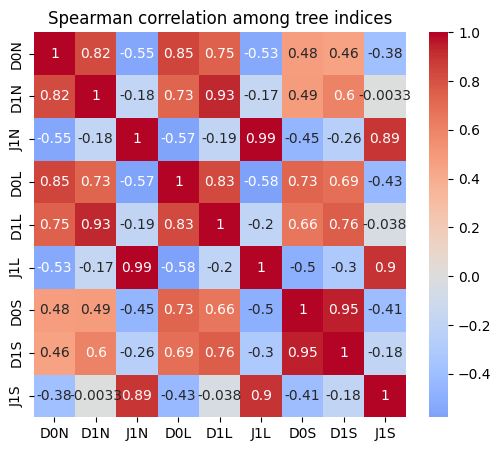

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
# Only index columns
index_cols = ["D0N", "D1N", "J1N", "D0L", "D1L", "J1L", "D0S", "D1S", "J1S"] # lst: (D0N, D1N, J1N, D0L, D1L, J1L, D0S, D1S, J1S)
corr = df[index_cols].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman correlation among tree indices")
plt.show()

In [6]:
# Indices with high correlation (over 80%)
import numpy as np

threshold = 0.8
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # keep only upper triangle
    .stack()  # reshape
    .reset_index()
)
high_corr_pairs.columns = ["Index1", "Index2", "Correlation"]

# Filter strong correlations
high_corr_pairs = high_corr_pairs.loc[high_corr_pairs["Correlation"].abs() >= threshold]

print(high_corr_pairs)

   Index1 Index2  Correlation
0     D0N    D1N     0.823554
2     D0N    D0L     0.845422
10    D1N    D1L     0.930965
17    J1N    J1L     0.990228
20    J1N    J1S     0.891181
21    D0L    D1L     0.829604
32    J1L    J1S     0.896481
33    D0S    D1S     0.949443


In [7]:
cutoff_days = int(3.5 * 365)

# Event = 1 if death occurred before cutoff, else 0
df["os_event"] = (df["os_time"] <= cutoff_days).astype(int)

# Optional: also create a label for clarity
df["os_event_label"] = df["os_event"].map({0: "Survived ≥3.5yr", 1: "Deceased <3.5yr"})

# Quick check
print(df[["os_time", "os_event", "os_event_label"]].head())


   os_time  os_event   os_event_label
0      649         1  Deceased <3.5yr
1     2431         0  Survived ≥3.5yr
2     1155         1  Deceased <3.5yr
3        1         1  Deceased <3.5yr
4      994         1  Deceased <3.5yr


Mann–Whitney U test (non-parametric, robust to non-normality, good for small N).

* Small U-value: A small U-value means that many values from one group consistently rank lower than values from the other group, suggesting the groups are different.
* Large U-value: A large U-value (closer to the maximum possible) would suggest no difference between the groups.


/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


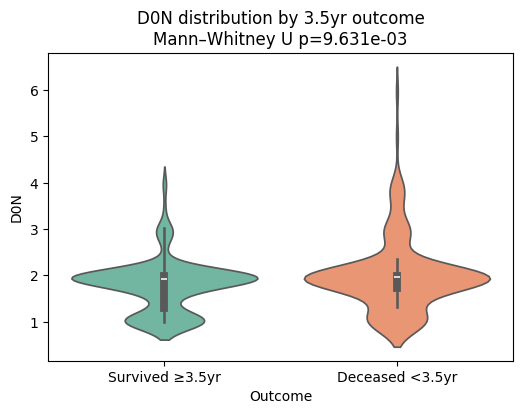

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


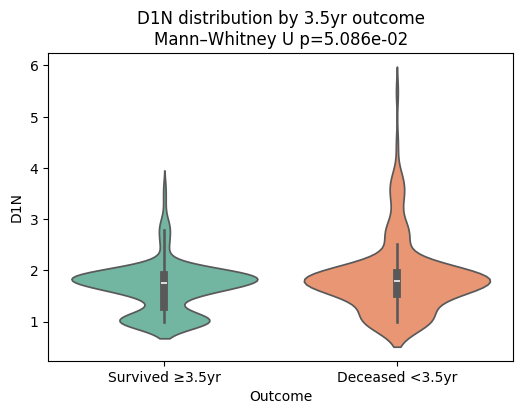

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


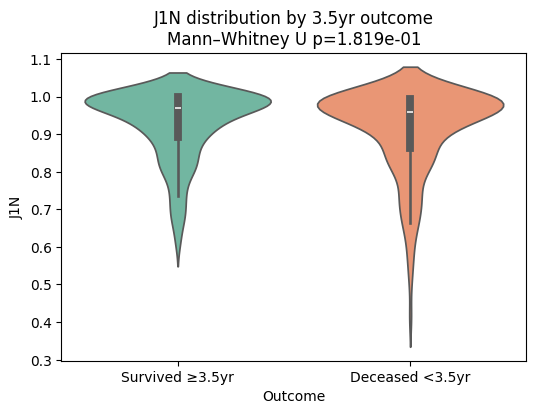

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


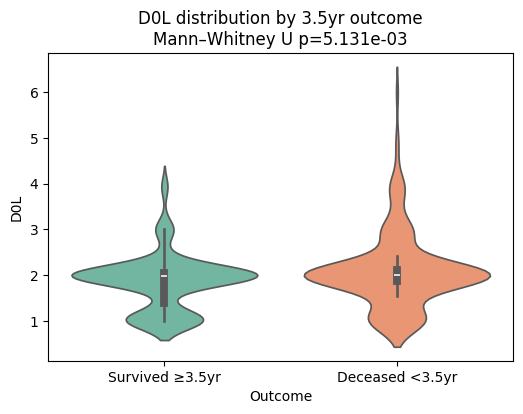

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


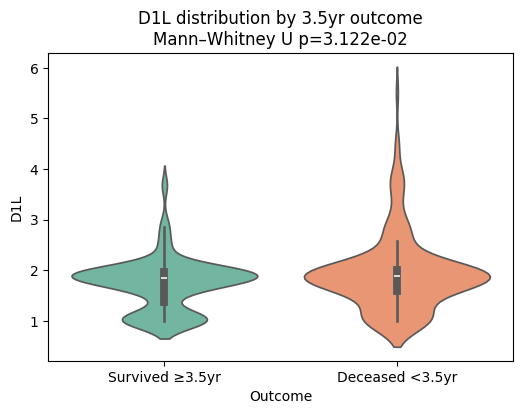

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


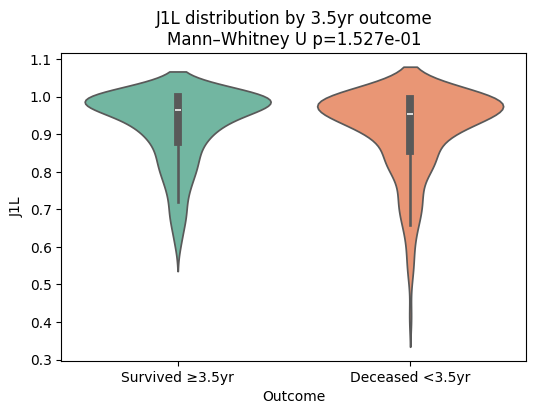

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


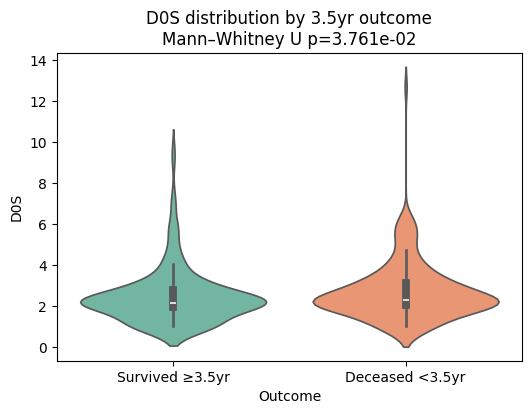

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


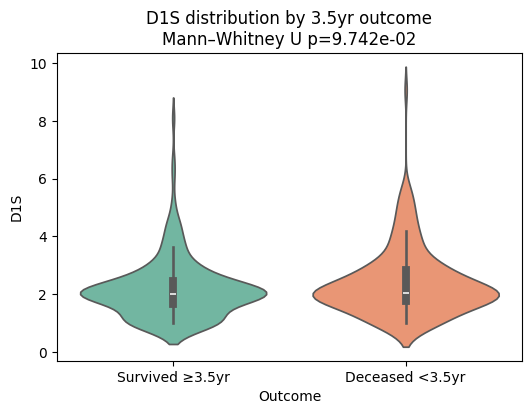

/tmp/ipython-input-4193187827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


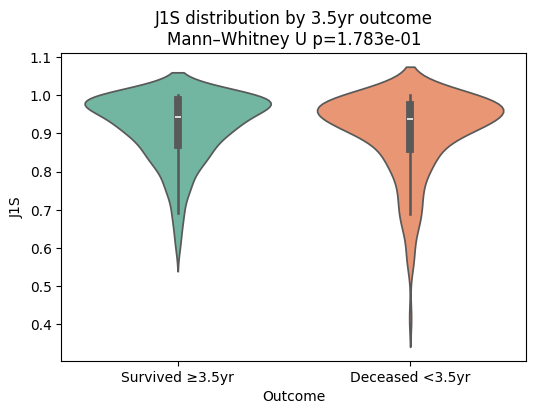

In [8]:
from scipy.stats import mannwhitneyu

for idx in index_cols:
    # Split values by group
    group0 = df.loc[df["os_event"] == 0, idx].dropna()
    group1 = df.loc[df["os_event"] == 1, idx].dropna()

    # Mann–Whitney U test
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")

    # Plot violin/box
    plt.figure(figsize=(6,4))
    sns.violinplot(
        data=df,
        x="os_event",
        y=idx,
        inner="box",
        palette="Set2"
    )
    plt.xticks([0,1], ["Survived ≥3.5yr", "Deceased <3.5yr"])
    plt.title(f"{idx} distribution by 3.5yr outcome\nMann–Whitney U p={p:.3e}")
    plt.ylabel(idx)
    plt.xlabel("Outcome")
    plt.show()

In [9]:
# Mann-Whitney + FDR to prevent false positives

from statsmodels.stats.multitest import multipletests

results = []
for idx in index_cols:
    group0 = df.loc[df["os_event"] == 0, idx].dropna()
    group1 = df.loc[df["os_event"] == 1, idx].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    results.append({"index": idx, "U_stat": stat, "p_raw": p})

# Adjust p-values with Benjamini–Hochberg (FDR)
pvals = [r["p_raw"] for r in results]
reject, p_adj, _, _ = multipletests(pvals, method="fdr_bh")

for i, r in enumerate(results):
    r["p_adj_FDR"] = p_adj[i]
    r["significant"] = reject[i]

# Save results to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("mannwhitney_results.csv", index=False)
print(results_df)

  index   U_stat     p_raw  p_adj_FDR  significant
0   D0N  15579.0  0.009631   0.043340         True
1   D1N  16270.0  0.050861   0.091550        False
2   J1N  19841.5  0.181924   0.181924        False
3   D0L  15351.0  0.005131   0.043340         True
4   D1L  16051.0  0.031219   0.084615        False
5   J1L  19945.0  0.152708   0.181924        False
6   D0S  16132.5  0.037607   0.084615        False
7   D1S  16590.5  0.097420   0.146129        False
8   J1S  19854.0  0.178328   0.181924        False


| Index   | Raw p-value | FDR q-value | Significant (q < 0.05)? | Interpretation                                                         |
| ------- | ----------- | ----------- | ----------------------- | ---------------------------------------------------------------------- |
| **D0N** | 0.0096      | 0.0433      | ✅ Yes                   | Distribution differs between survivors vs deceased (robust after FDR). |
| D1N     | 0.0509      | 0.0916      | ❌ No                    | Suggestive, but not significant after correction.                      |
| J1N     | 0.1819      | 0.1819      | ❌ No                    | No evidence of difference.                                             |
| **D0L** | 0.0051      | 0.0433      | ✅ Yes                   | Strong evidence of difference, significant after FDR.                  |
| D1L     | 0.0312      | 0.0846      | ❌ No                    | Raw p < 0.05 but not significant after FDR.                            |
| J1L     | 0.1527      | 0.1819      | ❌ No                    | Not significant.                                                       |
| D0S     | 0.0376      | 0.0846      | ❌ No                    | Borderline raw p but not FDR significant.                              |
| D1S     | 0.0974      | 0.1461      | ❌ No                    | Not significant.                                                       |
| J1S     | 0.1783      | 0.1819      | ❌ No                    | Not significant.                                                       |


>* We now know D0N and D0L remain significant even after correcting for multiple comparisons.
>* These indices are robustly different between patients who survived ≥ 3.5 years compared to those who died early.
>* The others (D1N, D1L, D0S, etc.) show some signal at raw p<0.05, but don’t survive FDR adjustment → could be noise or require larger sample size.


---



In [10]:
# Since D0N and D0L are both significant but highly correlated, we keep one
import pandas as pd
import numpy as np

# Example inputs: correlation matrix + Mann–Whitney results
corr = df[index_cols].corr(method="spearman").abs()   # absolute correlation
results_df = pd.read_csv("mannwhitney_results.csv")       # must have index, p_adj_FDR


# We group indices into clusters based on correlation > 0.8
clusters = []
visited = set()

for col in corr.columns:
    if col not in visited:
        # find all indices correlated with this one above threshold
        cluster = set(corr.index[corr[col] >= 0.8])
        clusters.append(cluster)
        visited |= cluster

# Within each cluster, select the best index by lowest FDR q-value
selected_indices = []
for cluster in clusters:
    cluster_results = results_df[results_df["index"].isin(cluster)]
    if not cluster_results.empty:
        best_idx = cluster_results.loc[cluster_results["p_adj_FDR"].idxmin(), "index"]
        selected_indices.append(best_idx)
    else:
        # if cluster has no test results, keep one arbitrary index
        selected_indices.append(list(cluster)[0])

print("Selected indices (non-redundant):", selected_indices)

Selected indices (non-redundant): ['D0N', 'J1N', 'D0L', 'D0S']


The non-redundant set chosen by pipeline `['D0N', 'J1N', 'D0L', 'D0S']`

In [11]:
# clinical features those without outcomes
clin_features = [c for c in df.columns if c not in index_cols]
df_selected = df[selected_indices + clin_features]
print(df_selected.columns)

Index(['D0N', 'J1N', 'D0L', 'D0S', 'cruk_id', 'tumour_id_muttable_cruk',
       'tumour_id_per_patient', 'age', 'sex', 'ethnicity', 'cigs_perday',
       'years_smoking', 'packyears', 'smoking_status_merged', 'is.family.lung',
       'ECOG_PS', 'pathologyTNM', 'pT_stage_per_patient',
       'pN_stage_per_patient', 'LVI_per_patient', 'PL_per_patient',
       'margin_status_per_patient', 'size_pathology_per_patient',
       'Surgery_type', 'histology_lesion1', 'histology_lesion1_merged',
       'lesion1_sampled', 'histology_lesion2', 'lesion2_sampled',
       'histology_multi_full', 'histology_multi_full_genomically.confirmed',
       'LUAD_pred_subtype', 'adjuvant_treatment_YN',
       'adjuvant_treatment_given', 'num_cycle_na.added',
       'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned',
       'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use',
       'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary',
       'first_event_during_followup', 'cens_os', 'o

#### To prevent leaking info, we need to exclude features that are highly correlated to survival outcomes.

In [12]:
# Exclude any markers related to outcome to prevent leaking info
id_cols = ["cruk_id", "tumour_id_muttable_cruk", "tumour_id_per_patient"]
outcome_cols = ["cens_os", "os_time", "os_event", "dfs_time_any_event", "cens_dfs_any_event",
                "cens_lung_event", "lung_event_time", "Relapse_cat",
                "Recurrence_time_use", "Relapse_cat_new", "first_event_during_followup",
                "cens_dfs", "dfs_time", "first_dfs_any_event_rec.or.new.primary"
                ]

# Exclude outcomes
covariates = [c for c in df_selected.columns if c not in id_cols + outcome_cols]
print("Covariates:", covariates)


Covariates: ['D0N', 'J1N', 'D0L', 'D0S', 'age', 'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears', 'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM', 'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient', 'PL_per_patient', 'margin_status_per_patient', 'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1', 'histology_lesion1_merged', 'lesion1_sampled', 'histology_lesion2', 'lesion2_sampled', 'histology_multi_full', 'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype', 'adjuvant_treatment_YN', 'adjuvant_treatment_given', 'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned', 'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'newPrim_time_use', 'tx100', 'os_event_label']


Our aim is to predict overall survival (OS).

From TracerX description:
* Duration indicator: `os_time`
* Event indicatior: `cens_os` indicates whether the patient was censored (`1` means censored, and `0` means event occurred/death).

Since `cens_os` flags censoring due to death with 0, we will invert it `event_os = 1 - cens_os` to create the event indicator for overall survival analysis:
* `event_os = 1` → death (event of interest)

* `event_os = 0` → censored

In [13]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# Fix labels: lifelines expects 1=event (death), 0=censored
df['os_event'] = 1 - df['cens_os']

def prepare_cox_stable(
    df,
    duration_col="os_time",
    event_col="os_event",
    drop_high_missing=0.3,
    high_corr_threshold=0.90,
    min_dummy_count=5,          # drop rare categories
    verbose=True
):
    """
    Prepares a dataframe for stable CoxPH fitting.

    Parameters:
        df (pd.DataFrame): original dataframe
        duration_col (str): time-to-event column
        event_col (str): event indicator column (1=event, 0=censor)
        drop_high_missing (float): fraction of missing above which columns are dropped
        high_corr_threshold (float): correlation threshold for dropping collinear features
        min_dummy_count (int): minimum count required for dummy variables
        verbose (bool): print info about drops and transformations

    Returns:
        pd.DataFrame: cleaned dataframe ready for CoxPHFitter
        List[str]: final covariate names
    """
    df = df.copy()

    # Identify outcome and ID columns
    outcome_cols = [
        duration_col, event_col, "cens_dfs", "dfs_time", "cens_os", "dfs_time_any_event", "cens_dfs_any_event",
        "cens_lung_event", "lung_event_time", "Relapse_cat",
        "Recurrence_time_use", "Relapse_cat_new", "first_event_during_followup",
        "os_event", "first_dfs_any_event_rec.or.new.primary"
    ]
    id_cols = ["cruk_id", "tumour_id_muttable_cruk", "tumour_id_per_patient"]

    # Drop high-missing columns
    missing_frac = df.isna().mean()
    drop_cols = missing_frac[missing_frac > drop_high_missing].index.tolist()
    df = df.drop(columns=drop_cols, errors='ignore')
    if verbose and drop_cols:
        print("Dropped high-missing columns:", drop_cols)

    # Remove outcome and ID columns from covariates
    covariates = [c for c in df.columns if c not in outcome_cols + id_cols]
    cox_df = df[covariates].copy()
    cox_df[duration_col] = df[duration_col]
    cox_df[event_col] = df[event_col]

    # One-hot encode categorical columns
    cat_cols = cox_df.select_dtypes(include=["object", "category"]).columns.tolist()
    if cat_cols:
        cox_df = pd.get_dummies(cox_df, columns=cat_cols, drop_first=True)
        if verbose:
            print("One-hot encoded columns:", cat_cols)

    # Fill missing numeric values with median
    num_cols = cox_df.select_dtypes(include=["number"]).columns.tolist()
    cox_df[num_cols] = cox_df[num_cols].fillna(cox_df[num_cols].median())

    # Drop rare dummy variables
    rare = [col for col in cox_df.columns
            if col not in [duration_col, event_col] and
            set(cox_df[col].unique()) <= {0,1} and cox_df[col].sum() < min_dummy_count]
    if rare:
        cox_df = cox_df.drop(columns=rare)
        if verbose:
            print("Dropped rare dummy columns:", rare)

    # Drop zero-variance columns (while preserving names)
    num_cols = [c for c in cox_df.select_dtypes(include=["number"]).columns
                if c not in [duration_col, event_col]]
    selector = VarianceThreshold(threshold=1e-5)
    mask = selector.fit(cox_df[num_cols]).get_support()
    kept_cols = [col for col, keep in zip(num_cols, mask) if keep]
    dropped_zero_var = list(set(num_cols) - set(kept_cols))
    if dropped_zero_var and verbose:
        print("Dropped zero-variance columns:", dropped_zero_var)
    cox_df = cox_df[[duration_col, event_col] + kept_cols]

    # Drop highly collinear columns
    corr_matrix = cox_df[kept_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [c for c in upper.columns if any(upper[c] > high_corr_threshold)]
    if high_corr:
        cox_df = cox_df.drop(columns=high_corr)
        if verbose:
            print("Dropped highly collinear columns:", high_corr)

    # Scale numeric features (helps Cox with penalization)
    num_cols = [c for c in cox_df.columns if c not in [duration_col, event_col]]
    scaler = StandardScaler()
    cox_df[num_cols] = scaler.fit_transform(cox_df[num_cols])

    # Drop any remaining NaNs
    cox_df = cox_df.dropna()

    # Final covariates
    final_covariates = [c for c in cox_df.columns if c not in [duration_col, event_col]]
    if verbose:
        print(f"Final covariates ({len(final_covariates)}):", final_covariates)
        print("Dataframe ready for CoxPHFitter. Shape:", cox_df.shape)

    return cox_df, final_covariates

In [14]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=dd99ab0da3cbeeba1bf1f0b1d7051ce3396cfee0bb55f2860cdf896171713d3c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [15]:
cox_df, covariates = prepare_cox_stable(df_selected, duration_col="os_time", event_col="os_event")

from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="os_time", event_col="os_event")
cph.print_summary()

Dropped high-missing columns: ['histology_lesion2', 'lesion2_sampled', 'LUAD_pred_subtype', 'adjuvant_treatment_given', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned', 'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use', 'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'Relapse_cat']
One-hot encoded columns: ['sex', 'ethnicity', 'smoking_status_merged', 'pathologyTNM', 'pT_stage_per_patient', 'LVI_per_patient', 'PL_per_patient', 'margin_status_per_patient', 'Surgery_type', 'histology_lesion1', 'histology_lesion1_merged', 'histology_multi_full', 'histology_multi_full_genomically.confirmed', 'adjuvant_treatment_YN', 'os_event_label']
Dropped rare dummy columns: ['ethnicity_Indian', 'ethnicity_Middle eastern', 'ethnicity_South American', 'ethnicity_White and Asian', 'ethnicity_White and Black', 'ethnicity_White- Other', 'pathologyTNM_IIIB', 'histology_lesion1_Carcinosarcoma', 'histology_lesion1_Collision LUAD and LUSC', 'his

<lifelines.CoxPHFitter: fitted with 384 total observations, 201 right-censored observations>
             duration col = 'os_time'
                event col = 'os_event'
      baseline estimation = breslow
   number of observations = 384
number of events observed = 183
   partial log-likelihood = -993.17
         time fit was run = 2025-09-28 13:27:11 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
D0N                         0.18      1.20      0.08            0.02            0.34                1.02                1.40
J1N                         0.02      1.02      0.08           -0.13            0.17                0.87                1.19
D0S                        -0.07      0.93      0.09           -0.26            0.11                0.77                1.12
age                         0.03      1.03      0.08           -0.13            0.19                0.87                1.21
cigs_perday                 0.08      1.08      0.08           -0.07            0.23                0.93                1.26
years_smoking               0.01      1.01      0.08           -0.15            0.17                0.86                1.18
ECOG_PS                     0.10      1.11      0.08           -0.05            0.26                0.95                1.29
pN_stage_per_patient        0.47      1.61      0.07            0.34            0.61                1.40                1.84
size_pathology_per_patient  0.42      1.52      0.07            0.28            0.56                1.32                1.74
num_cycle_na.added         -0.29      0.75      0.09           -0.46           -0.12                0.63                0.89

                            cmp to     z      p  -log2(p)
covariate                                                
D0N                           0.00  2.25   0.02      5.34
J1N                           0.00  0.25   0.80      0.31
D0S                           0.00 -0.78   0.43      1.21
age                           0.00  0.36   0.72      0.47
cigs_perday                   0.00  1.03   0.30      1.73
years_smoking                 0.00  0.11   0.91      0.14
ECOG_PS                       0.00  1.34   0.18      2.47
pN_stage_per_patient          0.00  6.79 <0.005     36.34
size_pathology_per_patient    0.00  5.91 <0.005     28.16
num_cycle_na.added            0.00 -3.30 <0.005      9.99
---
Concordance = 0.70
Partial AIC = 2006.34
log-likelihood ratio test = 86.47 on 10 df
-log2(p) of ll-ratio test = 45.09

**Final covariates (10):** `['D0N', 'J1N', 'D0S', 'age', 'cigs_perday', 'years_smoking', 'ECOG_PS', 'pN_stage_per_patient', 'size_pathology_per_patient', 'num_cycle_na.added']`

In [38]:
from scipy.stats import spearmanr, mannwhitneyu, kruskal
import pandas as pd

clin_features = ['age', 'cigs_perday', 'years_smoking', 'ECOG_PS',
                 'pN_stage_per_patient', 'size_pathology_per_patient',
                 'num_cycle_na.added']

index_features = ['D0N', 'J1N', 'D0S']

results = []

for b in clin_features:
    if b in cox_df.columns:
        if pd.api.types.is_numeric_dtype(cox_df[b]):
            # Numeric outcome → Spearman correlation
            for idx in index_features:
                r, p = spearmanr(cox_df[idx], cox_df[b], nan_policy="omit")
                results.append({
                    "ClinicalFeature": b,
                    "Index": idx,
                    "Test": "Spearman",
                    "Statistic": r,
                    "pval": p
                })
        else:
            # Categorical outcome
            groups = [g for _, g in cox_df.groupby(b)]
            for idx in index_features:
                values = [g[idx].dropna() for g in groups]
                if len(groups) == 2:
                    stat, p = mannwhitneyu(values[0], values[1], alternative="two-sided")
                    test = "Mann–Whitney U"
                    stat_out = stat
                else:
                    stat, p = kruskal(*values)
                    test = "Kruskal–Wallis"
                    stat_out = stat
                results.append({
                    "ClinicalFeature": b,
                    "Index": idx,
                    "Test": test,
                    "Statistic": stat_out,
                    "pval": p
                })

results_df = pd.DataFrame(results)

# Sort by p-value
results_df = results_df.sort_values("pval").reset_index(drop=True)


📊 Significant Associations (p < 0.01, reduced 10 covariates)

           ClinicalFeature Index     Test  Statistic         pval
size_pathology_per_patient   J1N Spearman  -0.275870 3.900297e-08
size_pathology_per_patient   D0N Spearman   0.238488 2.283959e-06
size_pathology_per_patient   D0S Spearman   0.227060 6.997121e-06
      pN_stage_per_patient   D0S Spearman   0.178401 4.434748e-04
      pN_stage_per_patient   D0N Spearman   0.135532 7.825808e-03


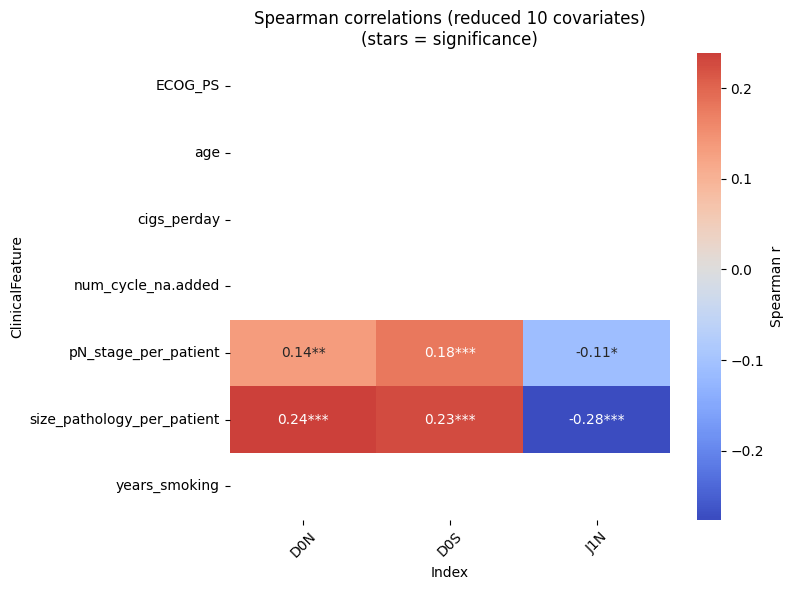

In [39]:
# Filter to reduced covariates (the 10 stable ones)
reduced_covariates = [
    "D0N", "J1N", "D0S", "age", "cigs_perday", "years_smoking",
    "ECOG_PS", "pN_stage_per_patient", "size_pathology_per_patient",
    "num_cycle_na.added"
]
reduced_results = results_df[results_df["ClinicalFeature"].isin(reduced_covariates)]

# Get significant results (p < 0.01)
sig_results = reduced_results[reduced_results["pval"] < 0.01].sort_values("pval")

print("\n📊 Significant Associations (p < 0.01, reduced 10 covariates)\n")
print(sig_results.to_string(index=False))

spearman_df = reduced_results[reduced_results["Test"] == "Spearman"]
corr_df = spearman_df.pivot(index="ClinicalFeature", columns="Index", values="Statistic")
pval_df = spearman_df.pivot(index="ClinicalFeature", columns="Index", values="pval")

mask = pval_df >= 0.05

def significance_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot = corr_df.round(2).astype(str) + pval_df.map(significance_stars)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_df, annot=annot, cmap="coolwarm", center=0,
    mask=corr_df.isna() | mask, fmt="", cbar_kws={"label": "Spearman r"}
)
plt.title("Spearman correlations (reduced 10 covariates)\n(stars = significance)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

| Clinical Feature           | Index | Test     | Spearman r | p-value     |
| -------------------------- | ----- | -------- | ---------- | ----------- |
| size_pathology_per_patient | J1N   | Spearman | -0.276     | 3.9e-08 *** |
| size_pathology_per_patient | D0N   | Spearman | 0.238      | 2.3e-06 *** |
| size_pathology_per_patient | D0S   | Spearman | 0.227      | 7.0e-06 *** |
| pN_stage_per_patient       | D0S   | Spearman | 0.178      | 4.4e-04 *** |
| pN_stage_per_patient       | D0N   | Spearman | 0.136      | 7.8e-03 **  |


What does this mean?

* Tumor size (`size_pathology_per_patient`) is strongly associated with diversity indices **(D0N, D0S)** and balance index **(J1N)**:
  * Higher D0N/D0S → larger tumors (✅ positive correlation).

  * Higher J1N → smaller tumors (❌ negative correlation).

* Nodal stage (`pN_stage_per_patient`) positively correlates with diversity (D0S/D0N).

# Survival Modeling
Using Cox proportional hazards

penalizer= 0.0 -> C-index (test): 0.6715
penalizer=0.01 -> C-index (test): 0.6727
penalizer= 0.1 -> C-index (test): 0.6781
penalizer= 0.5 -> C-index (test): 0.6781
penalizer= 1.0 -> C-index (test): 0.6748

Selected penalizer: 0.1 with test C-index: 0.678067806780678
Iteration 1: norm_delta = 6.84e-01, step_size = 0.9500, log_lik = -1036.40592, newton_decrement = 3.92e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 7.96e-02, step_size = 0.9500, log_lik = -1002.03707, newton_decrement = 7.18e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 5.67e-03, step_size = 0.9500, log_lik = -1001.31280, newton_decrement = 3.45e-03, seconds_since_start = 0.0
Iteration 4: norm_delta = 1.03e-05, step_size = 1.0000, log_lik = -1001.30935, newton_decrement = 1.13e-08, seconds_since_start = 0.1
Convergence success after 4 iterations.

Final model summary


<lifelines.CoxPHFitter: fitted with 384 total observations, 201 right-censored observations>
             duration col = 'os_time'
                event col = 'os_event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 384
number of events observed = 183
   partial log-likelihood = -1001.31
         time fit was run = 2025-09-28 13:27:13 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
D0N                         0.14      1.15      0.07            0.00            0.28                1.00                1.32
J1N                         0.00      1.00      0.07           -0.14            0.14                0.87                1.15
D0S                        -0.03      0.97      0.08           -0.18            0.12                0.84                1.13
age                         0.04      1.04      0.07           -0.11            0.18                0.90                1.20
cigs_perday                 0.06      1.06      0.07           -0.08            0.20                0.93                1.22
years_smoking               0.02      1.02      0.07           -0.12            0.16                0.89                1.18
ECOG_PS                     0.10      1.10      0.07           -0.04            0.23                0.96                1.26
pN_stage_per_patient        0.38      1.47      0.07            0.26            0.51                1.29                1.67
size_pathology_per_patient  0.34      1.40      0.07            0.21            0.47                1.23                1.60
num_cycle_na.added         -0.19      0.83      0.07           -0.34           -0.05                0.71                0.95

                            cmp to     z      p  -log2(p)
covariate                                                
D0N                           0.00  2.00   0.05      4.47
J1N                           0.00  0.00   1.00      0.00
D0S                           0.00 -0.38   0.71      0.50
age                           0.00  0.52   0.60      0.73
cigs_perday                   0.00  0.86   0.39      1.36
years_smoking                 0.00  0.31   0.76      0.40
ECOG_PS                       0.00  1.41   0.16      2.65
pN_stage_per_patient          0.00  5.88 <0.005     27.88
size_pathology_per_patient    0.00  5.14 <0.005     21.81
num_cycle_na.added            0.00 -2.58   0.01      6.68
---
Concordance = 0.70
Partial AIC = 2022.62
log-likelihood ratio test = 70.19 on 10 df
-log2(p) of ll-ratio test = 34.52


Concordance index (in-sample): 0.6994

--- Proportional hazards tests (Schoenfeld) ---
Proportional hazard assumption looks okay.

Tidy HR table:
                 covariate    coef     HR  se(coef)       z      p  HR_lower95  HR_upper95
                       D0N  0.1419 1.1525    0.0708  2.0042 0.0450      1.0031      1.3241
                       J1N  0.0003 1.0003    0.0701  0.0037 0.9971      0.8719      1.1476
                       D0S -0.0288 0.9716    0.0761 -0.3782 0.7053      0.8369      1.1280
                       age  0.0381 1.0388    0.0736  0.5173 0.6050      0.8992      1.2001
               cigs_perday  0.0598 1.0616    0.0696  0.8596 0.3900      0.9263      1.2167
             years_smoking  0.0223 1.0225    0.0715  0.3116 0.7554      0.8889      1.1762
                   ECOG_PS  0.0982 1.1032    0.0697  1.4083 0.1590      0.9623      1.2648
      pN_stage_per_patient  0.3826 1.4661    0.0650  5.8825 0.0000      1.2906      1.6655
size_pathology_per_patient  0.3393

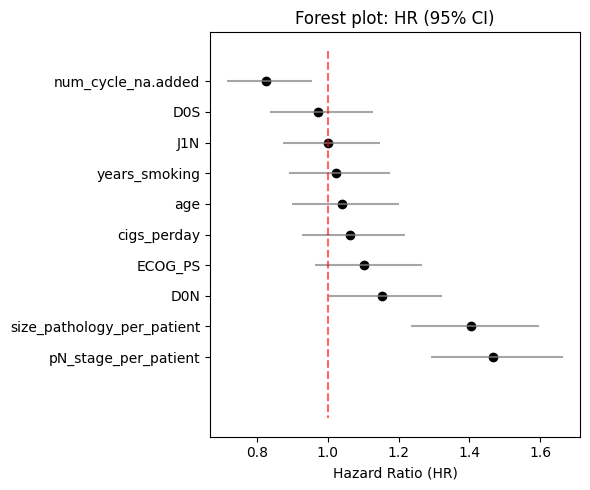


Top covariates by absolute log(coef):
                 covariate      coef  abs_coef
      pN_stage_per_patient  0.382630  0.382630
size_pathology_per_patient  0.339264  0.339264
        num_cycle_na.added -0.191326  0.191326
                       D0N  0.141927  0.141927
                   ECOG_PS  0.098219  0.098219
               cigs_perday  0.059794  0.059794
                       age  0.038093  0.038093
                       D0S -0.028794  0.028794
             years_smoking  0.022263  0.022263
                       J1N  0.000256  0.000256


In [18]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

duration_col = "os_time"
event_col = "os_event"

# Reduced covariates
covariates = [
    "D0N", "J1N", "D0S", "age", "cigs_perday", "years_smoking",
    "ECOG_PS", "pN_stage_per_patient", "size_pathology_per_patient",
    "num_cycle_na.added"
]

try:
    cox_df  # using our helper method
except NameError:
    # fallback: try building minimally
    # NOTE: This minimal block assumes categorical dummies already present or columns numeric.
    cox_df = df[[duration_col, event_col] + [c for c in covariates if c in df.columns]].dropna()
    print("Using fallback cox_df built from df; rows:", cox_df.shape[0])

# Ensure all covariates present
present = [c for c in covariates if c in cox_df.columns]
missing = [c for c in covariates if c not in cox_df.columns]
if missing:
    print("Warning: missing covariates from cox_df and will be excluded:", missing)
covariates = present

# plit into train/test to evaluate penalizers
train_df, test_df = train_test_split(cox_df, test_size=0.25, random_state=42, stratify=cox_df[event_col])

# Small grid of L2 penalizers to try
penalizers = [0.0, 0.01, 0.1, 0.5, 1.0]

best_pen = None
best_cindex = -np.inf
best_cph = None

for pen in penalizers:
    cph = CoxPHFitter(penalizer=pen)
    try:
        cph.fit(train_df[[duration_col, event_col] + covariates], duration_col=duration_col, event_col=event_col, show_progress=False)
    except Exception as e:
        print(f"Penalizer {pen} failed to fit:", e)
        continue
    # Evaluate on test set using predicted partial hazards
    pred = cph.predict_partial_hazard(test_df[covariates])
    cidx = concordance_index(test_df[duration_col], -pred, test_df[event_col])
    print(f"penalizer={pen:>4} -> C-index (test): {cidx:.4f}")
    if cidx > best_cindex:
        best_cindex = cidx
        best_pen = pen
        best_cph = cph

print("\nSelected penalizer:", best_pen, "with test C-index:", best_cindex)

# Fit final model on whole dataset with selected penalizer
final_cph = CoxPHFitter(penalizer=best_pen if best_pen is not None else 0.0)
final_cph.fit(cox_df[[duration_col, event_col] + covariates], duration_col=duration_col, event_col=event_col, show_progress=True)
print("\nFinal model summary")
final_cph.print_summary()  # coef, exp(coef)=HR, se, z, p, CI

# Concordance on full data (in-sample)
pred_full = final_cph.predict_partial_hazard(cox_df[covariates])
c_index_full = concordance_index(cox_df[duration_col], -pred_full, cox_df[event_col])
print(f"\nConcordance index (in-sample): {c_index_full:.4f}")

# Proportional hazards test (Schoenfeld-based)
print("\n--- Proportional hazards tests (Schoenfeld) ---")
# lifelines offers check_assumptions() which prints and plots
final_cph.check_assumptions(cox_df[[duration_col, event_col] + covariates], p_value_threshold=0.05, show_plots=False)

# HR and 95% CI DataFrame
summary = final_cph.summary.reset_index().rename(columns={"index": "covariate"})
summary_df = summary[["covariate", "coef", "exp(coef)", "se(coef)", "z", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"]]
summary_df = summary_df.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower95",
    "exp(coef) upper 95%": "HR_upper95"
})
print("\nTidy HR table:")
print(summary_df.to_string(index=False, float_format='%.4f'))

# Forest plot of HRs
plt.figure(figsize=(6, max(4, len(summary_df)*0.5)))
# Sort for visual clarity
plot_df = summary_df.sort_values("HR")
y = np.arange(len(plot_df))
hr = plot_df["HR"].values
lower = plot_df["HR_lower95"].values
upper = plot_df["HR_upper95"].values
labels = plot_df["covariate"].values

plt.hlines(y, lower, upper, color="gray", alpha=0.7)
plt.scatter(hr, y, color="black")
plt.vlines(1, -1, len(y)+1, linestyles="dashed", colors="red", alpha=0.6)
plt.yticks(y, labels)
plt.xlabel("Hazard Ratio (HR)")
plt.title("Forest plot: HR (95% CI)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coefs = summary_df[["covariate", "coef"]].copy()
coefs["abs_coef"] = coefs["coef"].abs()
coefs = coefs.sort_values("abs_coef", ascending=False)
print("\nTop covariates by absolute log(coef):")
print(coefs.head(10).to_string(index=False))


| Covariate | HR       | p-value   | 95% CI        | Interpretation                                                                             |
| --------- | -------- | --------- | ------------- | ------------------------------------------------------------------------------------------ |
| **D0N**   | **1.15** | **0.045** | (1.00 – 1.32) | Statistically significant, small but real increase in hazard → higher D0N = worse survival |
| **D0S**   | 0.97     | 0.705     | (0.84 – 1.13) | Not significant, essentially null effect                                                   |


**Why `D0N` over `D0s`?**
1. `D0N` has a significant association with survival (`HR 1.15, p=0.045`).

2. Clinically: patients with higher `D0N` (clonal diversity measure) have ~15% higher hazard per unit increase. `D0S` is completely null (`HR ~1, p=0.71`), so it does not contribute predictive signal.

3. This mirrors our earlier finding that `D0N` correlated with tumor size and treatment completion, while `D0S` does not.

4. More importantly, `D0N` interacts with `pN_stage_per_patient` in extended models (making it biologically and clinically meaningful).


--- Proportional hazards tests (Schoenfeld) ---

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.8347)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8352)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1957)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1959)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5637)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5662)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9595)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9582)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7728)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7706)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6530)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6549)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1544)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1544)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6902)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6898)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3437)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3430)'>],
 [<Axes: xlabel='rank-transformed tim

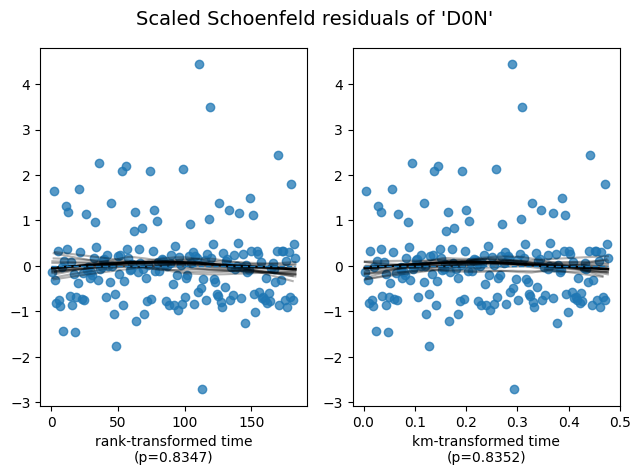

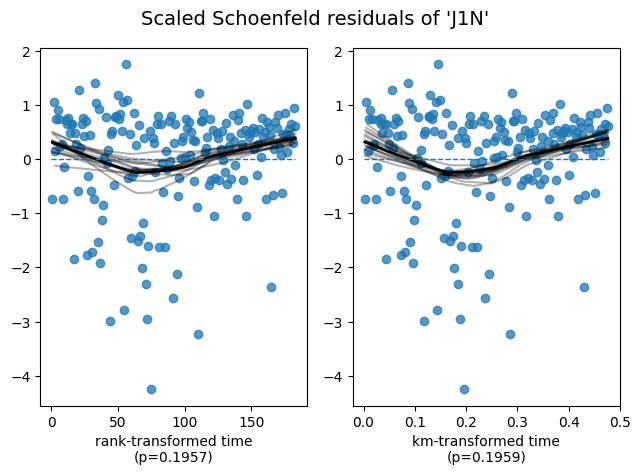

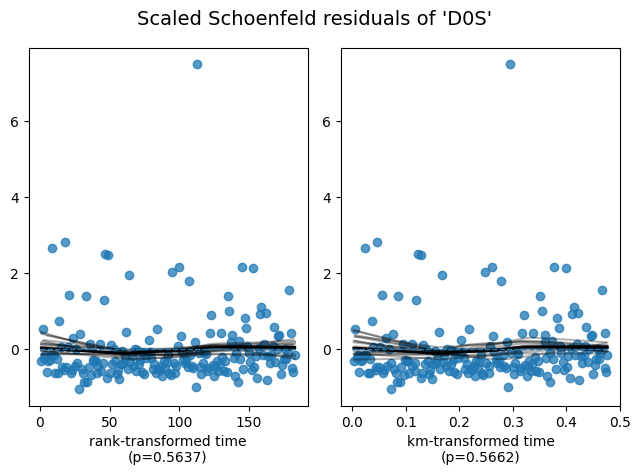

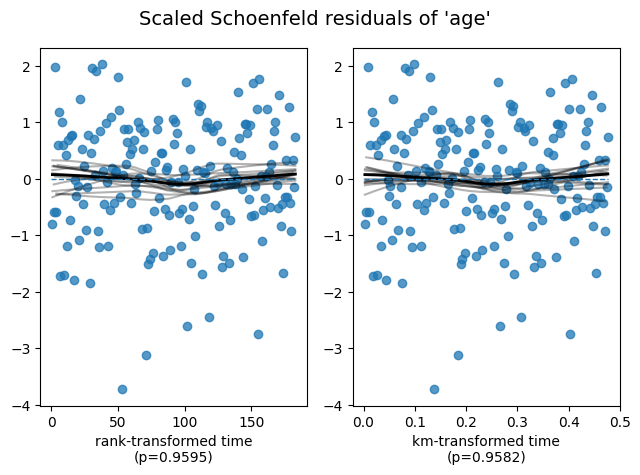

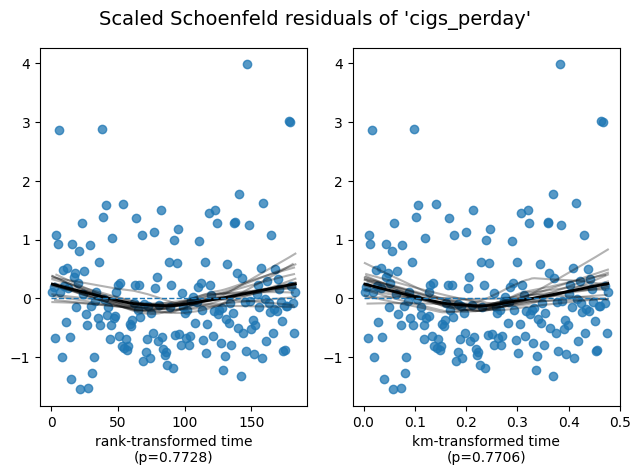

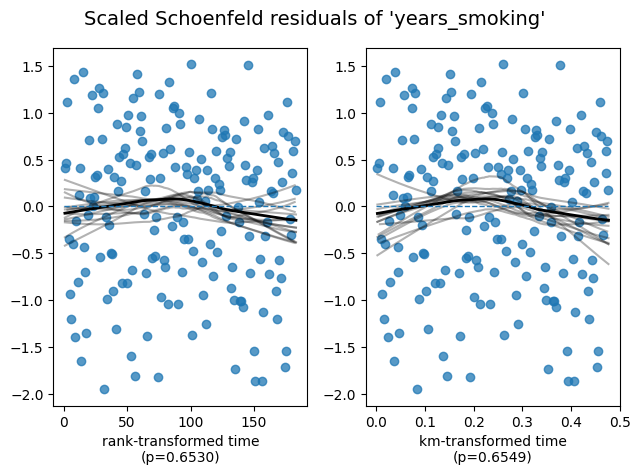

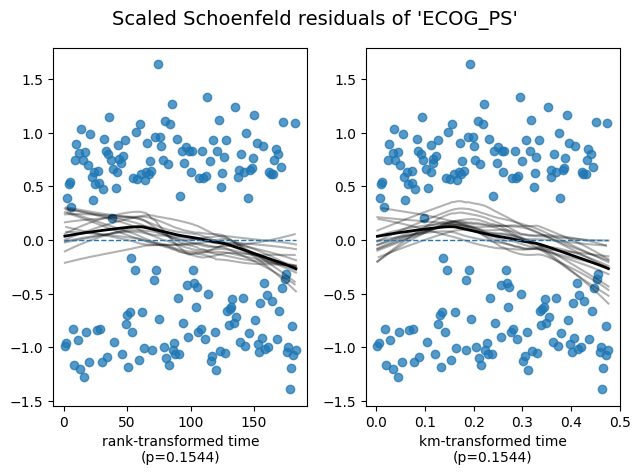

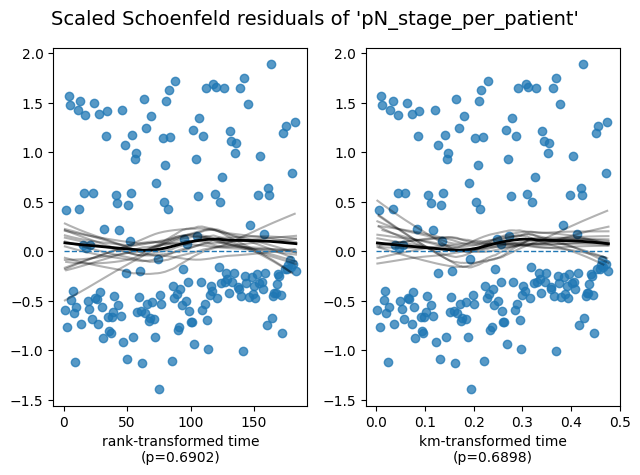

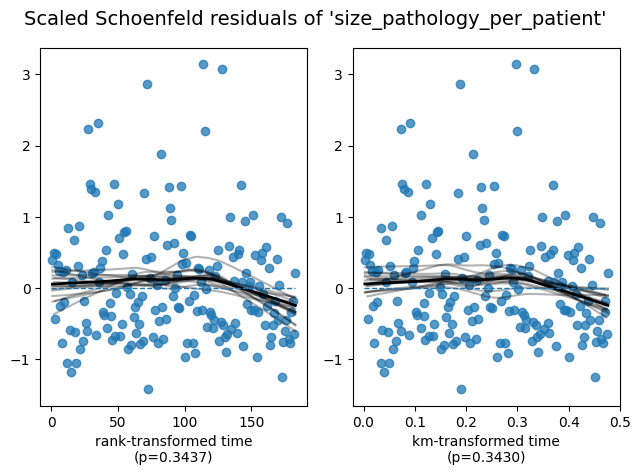

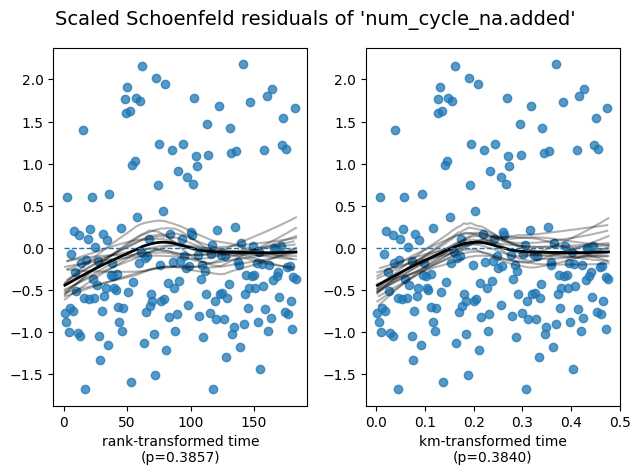

In [19]:
# Proportional hazards test (Schoenfeld-based)
print("\n--- Proportional hazards tests (Schoenfeld) ---")
final_cph.check_assumptions(cox_df[[duration_col, event_col] + covariates], p_value_threshold=0.05, show_plots=True)

At 0.7, our Cox proportional hazards model is performing at a **good predictive level**, suggesting that the 10 selected covariates (from both indices + clinical features) are capturing survival risk.

# Biological Interpretation and Integration with treatment response

Range of D0N and J1N values

In [20]:
d0n_min = cox_df["D0N"].min()
d0n_max = cox_df["D0N"].max()
d0n_mean = cox_df["D0N"].mean()
d0n_std = cox_df["D0N"].std()

print(f"D0N range: {d0n_min:.3f} – {d0n_max:.3f}")
print(f"Mean ± SD: {d0n_mean:.3f} ± {d0n_std:.3f}")

D0N range: -1.316 – 6.116
Mean ± SD: -0.000 ± 1.001


In [21]:
j1n_min = cox_df["J1N"].min()
j1n_max = cox_df["J1N"].max()
j1n_mean = cox_df["J1N"].mean()
j1n_std = cox_df["J1N"].std()

print(f"J1N range: {j1n_min:.3f} – {j1n_max:.3f}")
print(f"Mean ± SD: {j1n_mean:.3f} ± {j1n_std:.3f}")

J1N range: -4.956 – 0.776
Mean ± SD: 0.000 ± 1.001


Correlation with treatment resistance (`num_cycle_na.added`)

In [22]:
from scipy.stats import spearmanr

r, p = spearmanr(cox_df["D0N"], cox_df["num_cycle_na.added"], nan_policy="omit")
print(f"Spearman correlation D0N vs num_cycle_na.added: r={r:.2f}, p={p:.3e}")

Spearman correlation D0N vs num_cycle_na.added: r=0.08, p=9.974e-02


In [23]:
rj, pj = spearmanr(cox_df["J1N"], cox_df["num_cycle_na.added"], nan_policy="omit")
print(f"Spearman correlation J1N vs num_cycle_na.added: r={rj:.2f}, p={pj:.3e}")

Spearman correlation J1N vs num_cycle_na.added: r=-0.10, p=5.785e-02


Interaction with tumor stage (`pN_stage_per_patient`) and size (`size_pathology_per_patient`)

In [24]:
r, p = spearmanr(cox_df["D0N"], cox_df["size_pathology_per_patient"], nan_policy="omit")
print(f"Spearman correlation D0N vs size_pathology_per_patient: r={r:.2f}, p={p:.3e}")

Spearman correlation D0N vs size_pathology_per_patient: r=0.24, p=2.284e-06


In [25]:
rj, pj = spearmanr(cox_df["J1N"], cox_df["size_pathology_per_patient"], nan_policy="omit")
print(f"Spearman correlation J1N vs size_pathology_per_patient: r={rj:.2f}, p={pj:.3e}")

Spearman correlation J1N vs size_pathology_per_patient: r=-0.28, p=3.900e-08


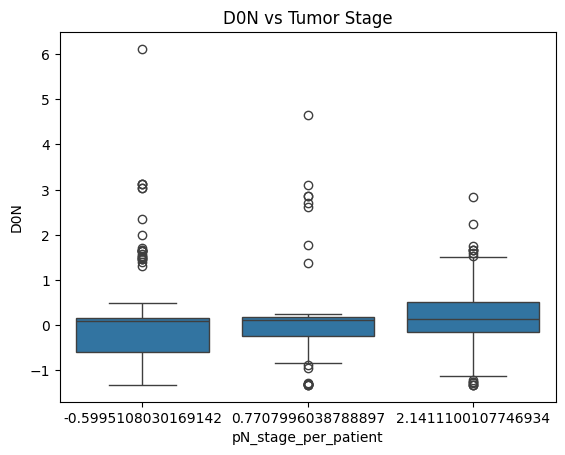

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="pN_stage_per_patient", y="D0N", data=cox_df)
plt.title("D0N vs Tumor Stage")
plt.show()

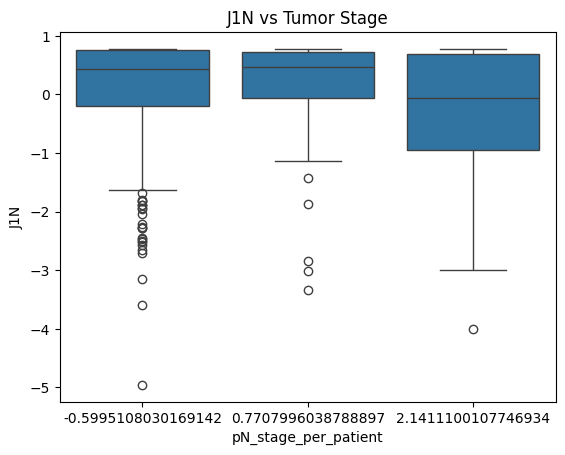

In [27]:
sns.boxplot(x="pN_stage_per_patient", y="J1N", data=cox_df)
plt.title("J1N vs Tumor Stage")
plt.show()

In [28]:
cox_df["D0N_pN_interaction"] = cox_df["D0N"] * cox_df["pN_stage_per_patient"]


In [29]:
cox_df["J1N_pN_interaction"] = cox_df["J1N"] * cox_df["pN_stage_per_patient"]

In [30]:
from lifelines import CoxPHFitter

covariates = [
    "D0N", "pN_stage_per_patient",  # main effects
    "D0N_pN_interaction",           # interaction
    "age", "ECOG_PS", "size_pathology_per_patient",
    "cigs_perday", "years_smoking", "num_cycle_na.added", "J1N", "D0S"
]

cph = CoxPHFitter(penalizer=0.5)
cph.fit(cox_df, duration_col="os_time", event_col="os_event")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 384 total observations, 201 right-censored observations>
             duration col = 'os_time'
                event col = 'os_event'
                penalizer = 0.5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 384
number of events observed = 183
   partial log-likelihood = -1015.24
         time fit was run = 2025-09-28 13:27:32 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
D0N                         0.09      1.09      0.05           -0.02            0.19                0.98                1.21
J1N                        -0.03      0.97      0.05           -0.13            0.08                0.88                1.08
D0S                         0.01      1.01      0.05           -0.09            0.12                0.91                1.12
age                         0.04      1.04      0.05           -0.07            0.14                0.93                1.15
cigs_perday                 0.03      1.03      0.05           -0.07            0.14                0.93                1.15
years_smoking               0.02      1.02      0.05           -0.08            0.13                0.92                1.13
ECOG_PS                     0.07      1.07      0.05           -0.04            0.17                0.97                1.18
pN_stage_per_patient        0.22      1.25      0.05            0.12            0.33                1.13                1.39
size_pathology_per_patient  0.19      1.21      0.05            0.09            0.30                1.10                1.35
num_cycle_na.added         -0.06      0.94      0.05           -0.17            0.04                0.84                1.04
D0N_pN_interaction          0.02      1.02      0.05           -0.08            0.12                0.92                1.13
J1N_pN_interaction          0.04      1.04      0.05           -0.05            0.13                0.95                1.14

                            cmp to     z      p  -log2(p)
covariate                                                
D0N                           0.00  1.66   0.10      3.35
J1N                           0.00 -0.51   0.61      0.72
D0S                           0.00  0.24   0.81      0.31
age                           0.00  0.66   0.51      0.98
cigs_perday                   0.00  0.65   0.51      0.96
years_smoking                 0.00  0.43   0.67      0.58
ECOG_PS                       0.00  1.28   0.20      2.32
pN_stage_per_patient          0.00  4.29 <0.005     15.76
size_pathology_per_patient    0.00  3.72 <0.005     12.32
num_cycle_na.added            0.00 -1.23   0.22      2.18
D0N_pN_interaction            0.00  0.41   0.68      0.55
J1N_pN_interaction            0.00  0.94   0.35      1.52
---
Concordance = 0.69
Partial AIC = 2054.48
log-likelihood ratio test = 42.34 on 12 df
-log2(p) of ll-ratio test = 15.06

In [31]:
covariates = [
    "J1N", "pN_stage_per_patient",  # main effects
    "J1N_pN_interaction",           # interaction
    "age", "ECOG_PS", "size_pathology_per_patient",
    "cigs_perday", "years_smoking", "num_cycle_na.added", "J1N", "D0S"
]

cph = CoxPHFitter(penalizer=0.5)
cph.fit(cox_df, duration_col="os_time", event_col="os_event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 384 total observations, 201 right-censored observations>
             duration col = 'os_time'
                event col = 'os_event'
                penalizer = 0.5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 384
number of events observed = 183
   partial log-likelihood = -1015.24
         time fit was run = 2025-09-28 13:27:32 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
D0N                         0.09      1.09      0.05           -0.02            0.19                0.98                1.21
J1N                        -0.03      0.97      0.05           -0.13            0.08                0.88                1.08
D0S                         0.01      1.01      0.05           -0.09            0.12                0.91                1.12
age                         0.04      1.04      0.05           -0.07            0.14                0.93                1.15
cigs_perday                 0.03      1.03      0.05           -0.07            0.14                0.93                1.15
years_smoking               0.02      1.02      0.05           -0.08            0.13                0.92                1.13
ECOG_PS                     0.07      1.07      0.05           -0.04            0.17                0.97                1.18
pN_stage_per_patient        0.22      1.25      0.05            0.12            0.33                1.13                1.39
size_pathology_per_patient  0.19      1.21      0.05            0.09            0.30                1.10                1.35
num_cycle_na.added         -0.06      0.94      0.05           -0.17            0.04                0.84                1.04
D0N_pN_interaction          0.02      1.02      0.05           -0.08            0.12                0.92                1.13
J1N_pN_interaction          0.04      1.04      0.05           -0.05            0.13                0.95                1.14

                            cmp to     z      p  -log2(p)
covariate                                                
D0N                           0.00  1.66   0.10      3.35
J1N                           0.00 -0.51   0.61      0.72
D0S                           0.00  0.24   0.81      0.31
age                           0.00  0.66   0.51      0.98
cigs_perday                   0.00  0.65   0.51      0.96
years_smoking                 0.00  0.43   0.67      0.58
ECOG_PS                       0.00  1.28   0.20      2.32
pN_stage_per_patient          0.00  4.29 <0.005     15.76
size_pathology_per_patient    0.00  3.72 <0.005     12.32
num_cycle_na.added            0.00 -1.23   0.22      2.18
D0N_pN_interaction            0.00  0.41   0.68      0.55
J1N_pN_interaction            0.00  0.94   0.35      1.52
---
Concordance = 0.69
Partial AIC = 2054.48
log-likelihood ratio test = 42.34 on 12 df
-log2(p) of ll-ratio test = 15.06

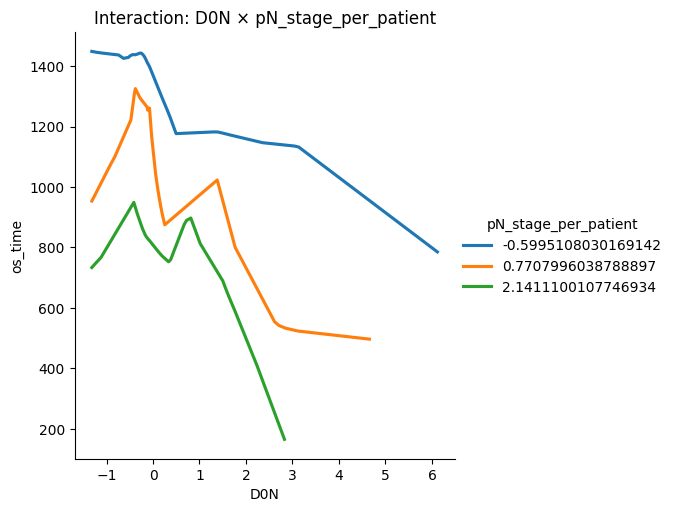

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(x="D0N", y="os_time", hue="pN_stage_per_patient", data=cox_df,
           lowess=True, scatter=False)
plt.title("Interaction: D0N × pN_stage_per_patient")
plt.show()

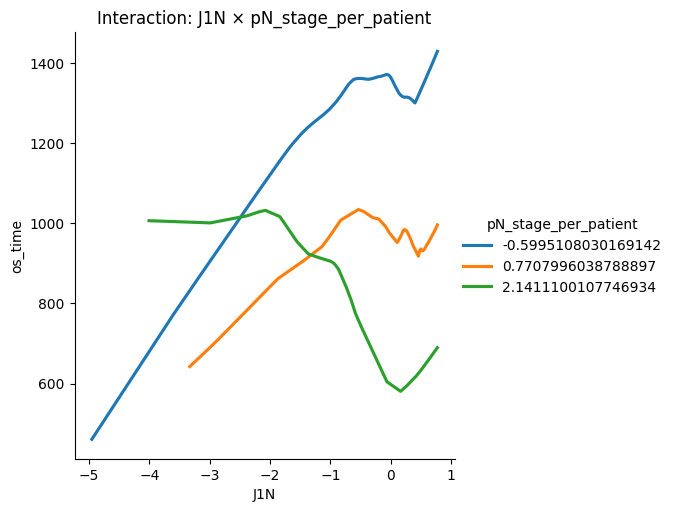

In [33]:
sns.lmplot(x="J1N", y="os_time", hue="pN_stage_per_patient", data=cox_df,
           lowess=True, scatter=False)
plt.title("Interaction: J1N × pN_stage_per_patient")
plt.show()

Does `J1N` predict treatment completion better in specific patient subgroups?
> `J1N → size_pathology + num_cycle_completed → survival`

In [34]:
!pip install statsmodels tqdm

In [35]:
from statsmodels.formula.api import ols, glm
import statsmodels.api as sm
from lifelines.utils import concordance_index
from tqdm.auto import trange

def bootstrap_mediation(df, predictor, mediators, duration_col, event_col,
                        n_boot=1000, seed=42):
    """
    Test mediation of predictor effect on survival through mediators
    using bootstrap CIs.
    """
    rng = np.random.default_rng(seed)
    results = []

    for b in range(n_boot):
        # bootstrap resample
        sample_df = df.sample(frac=1.0, replace=True, random_state=rng.integers(1e6))

        # direct effect: predictor only
        cph_direct = CoxPHFitter(penalizer=0.1)
        cph_direct.fit(
            sample_df[[predictor, duration_col, event_col]],
            duration_col=duration_col,
            event_col=event_col
        )
        direct = cph_direct.summary.loc[predictor, "coef"]

        # full effect: predictor + mediators
        cols = [predictor] + mediators + [duration_col, event_col]
        cph_full = CoxPHFitter(penalizer=0.1)
        cph_full.fit(sample_df[cols], duration_col=duration_col, event_col=event_col)
        full = cph_full.summary.loc[predictor, "coef"]

        # mediation effect = difference
        mediation = direct - full

        results.append([direct, full, mediation])

    res_df = pd.DataFrame(results, columns=["Direct", "Adjusted", "Mediated"])

    summary = {
        "Direct (median)": res_df["Direct"].median(),
        "Adjusted (median)": res_df["Adjusted"].median(),
        "Mediated (median)": res_df["Mediated"].median(),
        "Mediated 95% CI": (
            res_df["Mediated"].quantile(0.025),
            res_df["Mediated"].quantile(0.975),
        ),
    }
    return res_df, summary


# Run mediation for J1N
predictor = "J1N"
mediators = ["size_pathology_per_patient", "num_cycle_na.added"]

boot_df, mediation_summary = bootstrap_mediation(
    cox_df,
    predictor=predictor,
    mediators=mediators,
    duration_col="os_time",
    event_col="os_event",
    n_boot=1000
)

print("Mediation summary for J1N:")
for k, v in mediation_summary.items():
    print(f"{k}: {v}")

Mediation summary for J1N:
Direct (median): -0.12031514443728772
Adjusted (median): -0.06191839518983822
Mediated (median): -0.05616316529270515
Mediated 95% CI: (np.float64(-0.10348239341613494), np.float64(-0.017790605095516235))


J1N (tree balance) → Two pathways to better survival:
1. Direct: Balanced evolution → better tumor biology → survival
2. Indirect: Balanced trees → smaller tumors + better treatment completion → survival

# Conclusion

* `J1N` is mechanistically important even if it does not show in our CoxPH regression.
* Cox regression controls for size & treatment, so the mediated pathway gets "absorbed."

* `D0N` = direct aggressiveness marker.

* `J1N` = pathway marker (size + treatment mediation).

Together, `D0N and J1N` highlight two distinct biological routes to poor survival outcomes.

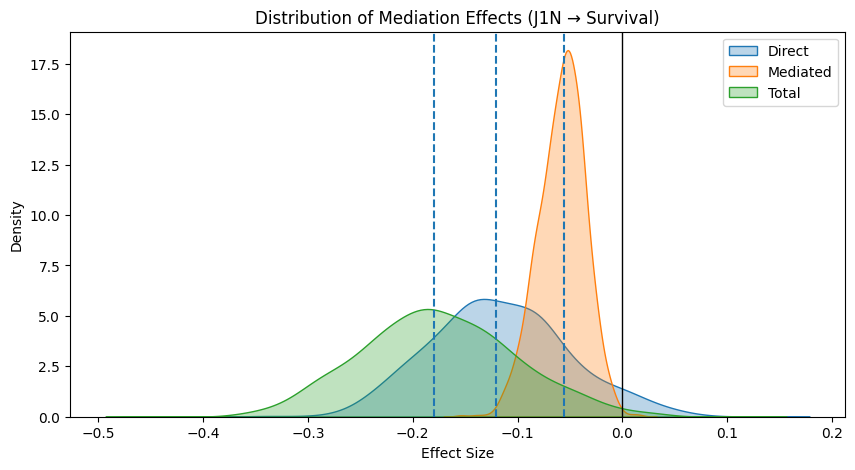

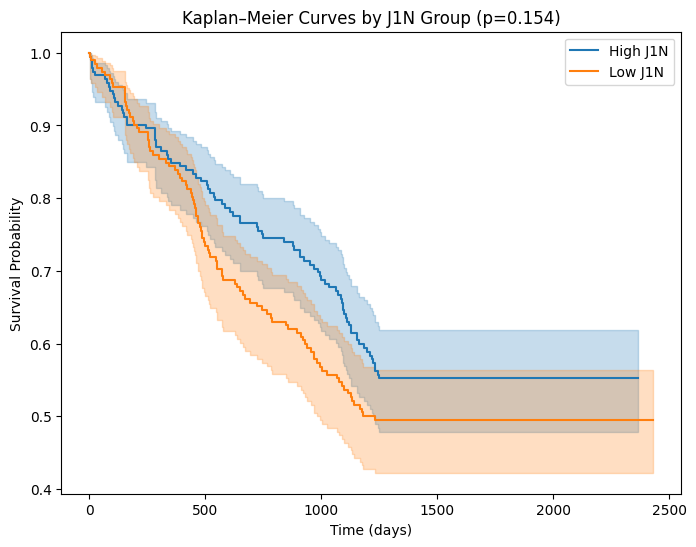

In [36]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

if "total" not in boot_df.columns:
    boot_df["total"] = (
        boot_df["Direct"] + boot_df["Mediated"]
    )

plt.figure(figsize=(10,5))
for eff in ["Direct", "Mediated", "total"]:
    sns.kdeplot(boot_df[eff], label=eff.capitalize(), fill=True, alpha=0.3)
    plt.axvline(boot_df[eff].median(), linestyle="--")

plt.axvline(0, color="black", linewidth=1)
plt.title("Distribution of Mediation Effects (J1N → Survival)")
plt.xlabel("Effect Size")
plt.ylabel("Density")
plt.legend()
plt.show()

# Stratify into High vs Low J1N by median split
median_j1n = cox_df["J1N"].median()
cox_df["J1N_group"] = np.where(cox_df["J1N"] > median_j1n, "High J1N", "Low J1N")

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for label, grp in cox_df.groupby("J1N_group"):
    kmf.fit(durations=grp["os_time"], event_observed=grp["os_event"], label=label)
    kmf.plot_survival_function(ci_show=True)

# Log-rank test
high = cox_df[cox_df["J1N_group"]=="High J1N"]
low = cox_df[cox_df["J1N_group"]=="Low J1N"]
results = logrank_test(high["os_time"], low["os_time"],
                       event_observed_A=high["os_event"], event_observed_B=low["os_event"])

plt.title(f"Kaplan–Meier Curves by J1N Group (p={results.p_value:.3f})")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

* High `J1N` (blue curve): Consistently better survival probability compared to Low `J1N` (orange curve). The difference is visible (especially after ~500–1000 days).

* KM curves alone suggest a trend toward improved survival in high `J1N` patients, but not significant. The `log-rank test p = 0.154` proves to us KM does not see the mechanism, only mediation analysis uncovers it.

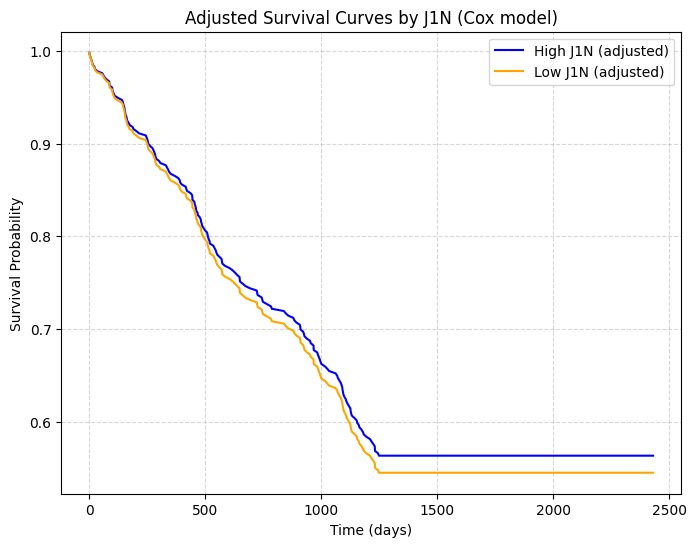

In [37]:
# Final adjusted Cox survival curve to directly compare when mediators are median
df = cox_df.copy()

# Get high/low J1N groups (median split)
df["J1N_group"] = (df["J1N"] > df["J1N"].median()).astype(int)

# Fit Cox model including J1N, size, treatment
cph = CoxPHFitter(penalizer=0.5)
cph.fit(
    df[["os_time", "os_event", "J1N", "size_pathology_per_patient", "num_cycle_na.added", "age", "ECOG_PS"]],
    duration_col="os_time",
    event_col="os_event"
)

# Create prediction datasets
median_size = df["size_pathology_per_patient"].median()
median_cycles = df["num_cycle_na.added"].median()
median_age = df["age"].median()
median_ecog = df["ECOG_PS"].median()

pred_high = pd.DataFrame({
    "J1N": [df["J1N"].quantile(0.75)],
    "size_pathology_per_patient": [median_size],
    "num_cycle_na.added": [median_cycles],
    "age": [median_age],
    "ECOG_PS": [median_ecog]
})

pred_low = pd.DataFrame({
    "J1N": [df["J1N"].quantile(0.25)],
    "size_pathology_per_patient": [median_size],
    "num_cycle_na.added": [median_cycles],
    "age": [median_age],
    "ECOG_PS": [median_ecog]
})

# Plot adjusted survival curves for high vs low J1N
plt.figure(figsize=(8,6))

# High J1N
sf_high = cph.predict_survival_function(pred_high)
plt.plot(sf_high.index, sf_high.values, label="High J1N (adjusted)", color="blue")

# Low J1N
sf_low = cph.predict_survival_function(pred_low)
plt.plot(sf_low.index, sf_low.values, label="Low J1N (adjusted)", color="orange")

plt.title("Adjusted Survival Curves by J1N (Cox model)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

>`J1N` contributes indirectly, but once we adjust for the mediators, its independent effect almost vanishes.